<div>
Olá, Raphael!

Meu nome é Luiz. Fico feliz em revisar seu projeto. Ao longo do texto farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender o meu feedback no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítico, mas que pode ser corrigido para melhoria geral no seu código/análise.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser arrumado, caso contrário seu projeto **não** será aceito.
</div>

Você pode interagir comigo através dessa célula:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

Objetivo
O objetivo deste projeto é analisar dados de telecomunicações para compreender o comportamento dos usuários, identificar padrões de uso e avaliar a eficiência operacional do serviço. A partir da exploração, limpeza e análise estatística dos dados, buscamos revelar tendências temporais, diferenças entre planos tarifários, sazonalidades e potenciais anomalias. Esses insights servirão de base para a definição de KPIs, construção de visualizações e elaboração de recomendações que apoiem decisões estratégicas e melhorias no serviço.

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import numpy as np

In [84]:
import os
print("Diretório atual:", os.getcwd())
print("Arquivos no diretório atual:", os.listdir('.'))



Diretório atual: /app
Arquivos no diretório atual: ['dados_uso_plano_telecom.csv', '.ipynb_checkpoints', 'notebook.ipynb']


In [85]:
import os

def listar_arquivos_recursivo(diretorio):
    for root, dirs, files in os.walk(diretorio):
        level = root.replace(diretorio, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 2 * (level + 1)
        for file in files:
            print(f'{subindent}{file}')

print("Estrutura completa de arquivos:")
listar_arquivos_recursivo('/app')

Estrutura completa de arquivos:
app/
  dados_uso_plano_telecom.csv
  notebook.ipynb
  .ipynb_checkpoints/
    notebook-checkpoint.ipynb


In [86]:
import os
if os.path.exists('/datasets/'):
    print("Arquivos em /datasets/:")
    print(os.listdir('/datasets/'))
else:
    print("Pasta /datasets/ não encontrada")

Arquivos em /datasets/:
['user_source_us.csv', 'retail_dataset.csv', 'games_data.csv', 'costs_info_short.csv', 'taxi.csv', 'urbanization.csv', 'command_line.csv', 'visittrrrt333.csv', 'segments.csv', 'memosky_test_03.csv', 'support_eng.csv', 'TestingWith_Age_ExpDays.xlsx', 'real_estate_data_old', 'drink_pref_cleaned_esp.csv', 'ch04_final_orders.csv', 'result_analysis_events.csv', 'final_ab_new_users.csv', 'support_data.csv', 'music_log_upd_nan.csv', 'train_ml.csv', 'data_gas_en.csv', 'b.txt', 'ывс', 'OnlineRetail.csv', 'query_1.csv', 'project_sql_result_03.csv', 'ticket_data_new.csv', 'gold_recovery_full.csv', 'menu_items.csv', 'three_more_games.csv', 'tweets_lemm.csv', 'mobile_stats.csv', 'languages_websites_idn.csv', 'test_data_n.csv', 'rest_data_us_upd.csv', 'orders_us.csv', 'test_new_efs.csv', 'ch02_problems02_events.csv', 'stores', 'contract.csv', 'plans.csv', 'tomtom_traffic.csv', 'project_sql_result_01 new.csv', 'merged_left.csv', 'books.csv', 'support_data_usa.csv', 'ad_data.cs

In [87]:
df_calls = pd.read_csv('/datasets/telecom_dataset.csv')

df_clients = pd.read_csv('/datasets/telecom_clients.csv')



In [88]:
print(df_calls.info())
print(df_calls.head())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
None
   user_id                       date direction internal  operator_id  \
0   166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1   166377  2019-08-05 00:00:00+03:00       out     True     880022.0   
2   166377  2019-08-05 00:00:00+03:00       out

In [89]:
print(df_clients.info())
print(df_clients.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB
None
   user_id tariff_plan  date_start
0   166713           A  2019-08-15
1   166901           A  2019-08-23
2   168527           A  2019-10-29
3   167097           A  2019-09-01
4   168193           A  2019-10-16


In [90]:
df_calls.isna().sum()


user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

A coluna operator_id apresenta 8.172 valores ausentes (15,1%), indicando que parte das chamadas não possui operador associado. Será necessário investigar se esses nulos correspondem a chamadas perdidas, internas ou automáticas.

In [91]:
df_calls.duplicated().sum()

4900

In [92]:
duplicados = df_calls[df_calls.duplicated(keep=False)]

duplicados.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
6,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,True,8,0,50
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,True,8,0,50
27,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
28,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
38,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3


In [93]:
df_calls = df_calls.drop_duplicates()


In [94]:
df_calls.duplicated().sum()

0

Identificámos 4.900 linhas duplicadas no dataset. A análise mostrou que são duplicados perfeitos, ou seja, todas as colunas possuem os mesmos valores e representam a mesma chamada registrada mais de uma vez. Esses registros serão removidos na implementação para evitar distorções nas métricas, sem impacto negativo nas análises já realizadas.

O dataset apresenta 4.900 registros duplicados (9,08%), indicando possível redundância nos logs de chamadas. Será necessário investigar se esses duplicados representam múltiplas chamadas agregadas ou erros de registro.

In [95]:

df_calls.describe()



,user_id,operator_id,calls_count,call_duration,total_call_duration
count,49002.000000,41546.000000,49002.000000,49002.000000,49002.000000
mean,167294.892759,916523.315409,16.462777,866.282091,1156.558202
std,598.558965,21230.041008,63.604098,3775.503352,4451.473661
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900790.500000,1.000000,0.000000,46.000000
50%,167158.000000,913938.000000,4.000000,37.000000,208.000000
75%,167819.000000,937708.000000,12.000000,570.000000,901.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


A análise estatística descritiva mostra que o dataset apresenta forte assimetria nas variáveis relacionadas a chamadas. As colunas call_duration e total_call_duration possuem valores máximos extremamente elevados (cerca de 40 e 46 horas, respectivamente), indicando a presença de outliers significativos. A variável calls_count também apresenta grande dispersão, com valores que chegam a 4.817 chamadas em um único registro. Já operator_id e user_id exibem variação limitada e comportamento consistente com identificadores numéricos. Esses resultados reforçam a necessidade de tratamento de outliers e validação de inconsistências antes das análises finais.

In [96]:
(df_calls['direction'].value_counts(normalize=True) * 100).round(2)



out    59.18
in     40.82
Name: direction, dtype: float64

A coluna direction apresenta 59% de chamadas de saída e 41% de entrada, indicando que os usuários realizam mais chamadas do que recebem.

In [97]:
df_calls['is_missed_call'].value_counts()


False    27549
True     21453
Name: is_missed_call, dtype: int64

A coluna is_missed_call revela que 43,7% das chamadas são perdidas, um valor elevado que pode indicar gargalos operacionais ou baixa capacidade de atendimento.

In [98]:
df_calls['internal'].value_counts(dropna=False)


False    43239
True      5653
NaN        110
Name: internal, dtype: int64

A coluna internal mostra que 88,2% das chamadas não são internas, enquanto 11,5% são internas. Além disso, há 110 registros (0,22%) com valor ausente, indicando a necessidade de tratamento desses casos antes das análises finais.

In [99]:
df_calls['operator_id'].nunique()


1092

A coluna operator_id possui 1.092 valores únicos, indicando que o identificador provavelmente representa filas, grupos ou sistemas automáticos, e não operadores individuais.

In [100]:
df_clients['tariff_plan'].value_counts()


C    395
B    261
A     76
Name: tariff_plan, dtype: int64

A distribuição dos planos tarifários é bastante desigual: 54% dos clientes estão no plano C, 36% no plano B e apenas 10% no plano A. Isso sugere diferenças significativas de adesão entre os planos, que devem ser investigadas.

In [101]:
df_calls['user_id'].nunique()


307

Apenas 307 dos 732 clientes (41,9%) possuem registros no dataset de chamadas. Isso significa que 58,1% dos clientes não apresentam histórico de chamadas, o que pode indicar inatividade, ausência de uso do serviço ou inconsistências no registro de dados.”

In [102]:
df_calls['date'] = pd.to_datetime(df_calls['date'], errors='coerce')
df_clients['date_start'] = pd.to_datetime(df_clients['date_start'], errors='coerce')

Conversão de tipos de dados (datas):  
Converter as colunas date e date_start para o tipo datetime, garantindo consistência temporal e permitindo análises cronológicas corretas. Essa operação é estrutural e não altera o conteúdo analítico do dataset.

In [103]:
set(df_calls['user_id']) - set(df_clients['user_id'])


set()

In [104]:
daily_calls = df_calls.groupby(df_calls['date'].dt.date).size()


daily_calls.head()

date
2019-08-02     8
2019-08-03     8
2019-08-04     4
2019-08-05    16
2019-08-06    21
dtype: int64

Padrões de uso ao longo do tempo:  
Ao agrupar o volume de chamadas por dia, observamos uma tendência crescente no início do período analisado, com o número diário de chamadas aumentando progressivamente entre 02/08 e 06/08. Esse comportamento indica intensificação do uso ao longo dos dias.

In [105]:

df_calls['weekday'] = df_calls['date'].dt.day_name()


weekday_calls = df_calls['weekday'].value_counts().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

weekday_calls


Monday       8143
Tuesday      9028
Wednesday    9049
Thursday     9265
Friday       8304
Saturday     2961
Sunday       2252
Name: weekday, dtype: int64

Sazonalidade semanal:  
A distribuição de chamadas por dia da semana mostra um padrão claro: o volume é significativamente maior de segunda a sexta, atingindo o pico na quinta-feira, enquanto sábado e domingo apresentam forte redução. Esse comportamento evidencia uma sazonalidade semanal típica de uso concentrado em dias úteis.

In [106]:

df_calls['hour'] = df_calls['date'].dt.hour


hourly_calls = df_calls['hour'].value_counts().sort_index()

hourly_calls


0    49002
Name: hour, dtype: int64

Sazonalidade por horário:  
A análise horária não pôde ser realizada, pois todas as chamadas estão registradas com hora igual a zero. Isso indica que o dataset não possui granularidade horária, impossibilitando a identificação de padrões de uso ao longo do dia.

In [107]:
df_calls_com_plano = df_calls.merge(
    df_clients[['user_id', 'tariff_plan']], 
    on='user_id', 
    how='left'
)


In [108]:

monthly_by_plan = df_calls_com_plano.groupby(['tariff_plan', 'month'])['calls_count'].sum()


KeyError: 'month'

In [109]:
print(df_calls_com_plano.columns.tolist())

# Verifique se há dados de plano
print(df_calls_com_plano['tariff_plan'].value_counts())

['user_id', 'date', 'direction', 'internal', 'operator_id', 'is_missed_call', 'calls_count', 'call_duration', 'total_call_duration', 'weekday', 'hour', 'tariff_plan']
C    18209
B    17237
A    13556
Name: tariff_plan, dtype: int64


In [110]:

# Criar coluna com o mês da chamada no DataFrame correto
df_calls_com_plano['month'] = df_calls_com_plano['date'].dt.to_period('M')

# Agrupar por plano e mês, somando o número de chamadas
monthly_by_plan = df_calls_com_plano.groupby(['tariff_plan', 'month'])['calls_count'].sum()

monthly_by_plan


/.venv/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1101: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(


tariff_plan  month  
A            2019-08     22970
             2019-09     86885
             2019-10    181688
             2019-11    148107
B            2019-08     11702
             2019-09     25975
             2019-10     56356
             2019-11     69540
C            2019-08      2719
             2019-09     33730
             2019-10     78255
             2019-11     88782
Name: calls_count, dtype: int64

Evolução por plano:  
A análise mensal do volume de chamadas por plano tarifário mostra crescimento consistente ao longo do período para todas as categorias. O plano A apresenta o maior volume absoluto, enquanto os planos B e C exibem taxas de crescimento mais aceleradas, especialmente o plano C, que evolui de um uso muito baixo em agosto para um volume elevado em novembro. Esses resultados indicam diferenças claras de comportamento entre os planos e uma tendência geral de aumento no uso do serviço.

Teste de Hipótese — Baixa Adesão ao Serviço
H0: A proporção de clientes que utilizam o serviço de chamadas é maior ou igual a 50%.
H1: A proporção de clientes que utilizam o serviço de chamadas é menor que 50%.



In [111]:
clientes_totais = df_clients['user_id'].nunique()
clientes_com_chamadas = df_calls['user_id'].nunique()

taxa_adesao = clientes_com_chamadas / clientes_totais
taxa_adesao


0.41939890710382516

Conclusão:  
Como 0.4194 < 0.50, rejeito H0 e aceito H1.
Há baixa adesão ao serviço de chamadas.

Teste de Hipótese — Outliers Distorcem a Duração das Chamadas
H0: A remoção de outliers não altera significativamente as métricas de duração das chamadas.
H1: A remoção de outliers altera significativamente as métricas de duração das chamadas.

In [112]:

df_calls['call_duration'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])


count     49002.000000
mean        866.282091
std        3775.503352
min           0.000000
50%          37.000000
75%         570.000000
90%        2092.000000
95%        3725.950000
99%       10314.910000
max      144395.000000
Name: call_duration, dtype: float64

In [113]:


Q1 = df_calls['call_duration'].quantile(0.25)
Q3 = df_calls['call_duration'].quantile(0.75)


IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

limite_superior, limite_inferior


(1425.0, -855.0)

In [114]:
df_sem_outliers = df_calls[df_calls['call_duration'] <= 1430]

df_calls['call_duration'].describe(), df_sem_outliers['call_duration'].describe()


(count     49002.000000
 mean        866.282091
 std        3775.503352
 min           0.000000
 25%           0.000000
 50%          37.000000
 75%         570.000000
 max      144395.000000
 Name: call_duration, dtype: float64,
 count    42153.000000
 mean       185.843451
 std        325.381223
 min          0.000000
 25%          0.000000
 50%          0.000000
 75%        226.000000
 max       1430.000000
 Name: call_duration, dtype: float64)

Resultado observado:  
Após remover valores acima de 1430 segundos (limite do IQR), a média caiu de 866s para 185s e o desvio padrão de 3731s para 325s, indicando forte impacto dos outliers.

Conclusão:  
Rejeito H0 e aceito H1.
Os outliers distorcem significativamente as métricas de duração das chamadas.

Teste de Hipótese — Planos Diferentes Geram Níveis Diferentes de Uso. 
H0: O número médio de chamadas por cliente é igual entre os planos A, B e C.
H1: O número médio de chamadas por cliente é diferente entre os planos A, B e C.

In [115]:
chamadas_por_cliente = df_calls.groupby('user_id').size().reset_index(name='num_chamadas')
chamadas_por_cliente.head()


,user_id,num_chamadas
0,166377,519
1,166391,20
2,166392,93
3,166399,20
4,166405,962


In [116]:
df_uso_plano = chamadas_por_cliente.merge(
    df_clients[['user_id', 'tariff_plan']],
    on='user_id',
    how='left'
)

df_uso_plano.head()


,user_id,num_chamadas,tariff_plan
0,166377,519,B
1,166391,20,C
2,166392,93,C
3,166399,20,C
4,166405,962,B


In [117]:
df_uso_plano.groupby('tariff_plan')['num_chamadas'].mean()


tariff_plan
A    398.705882
B    153.901786
C    113.099379
Name: num_chamadas, dtype: float64

Resultado observado:  
As médias de chamadas por cliente variam fortemente entre os planos:

Plano A: 438 chamadas

Plano B: 169 chamadas

Plano C: 124 chamadas

A diferença é grande e consistente.

Conclusão:  
Rejeito H0 e aceito H1.
Os planos tarifários influenciam significativamente o uso do serviço de chamadas.

KPIs

Os KPIs selecionados foram definidos para fornecer uma visão clara e estratégica sobre o funcionamento do serviço, permitindo avaliar:

a qualidade operacional,

o engajamento dos clientes,

e o desempenho dos planos tarifários.

Esses indicadores são essenciais para validar as hipóteses do projeto e orientar decisões de negócio baseadas em evidências.

KPIs

Os KPIs selecionados foram definidos para fornecer uma visão clara e estratégica sobre o funcionamento do serviço, permitindo avaliar:

a qualidade operacional,

o engajamento dos clientes,

e o desempenho dos planos tarifários.

Esses indicadores são essenciais para validar as hipóteses do projeto e orientar decisões de negócio baseadas em evidências.

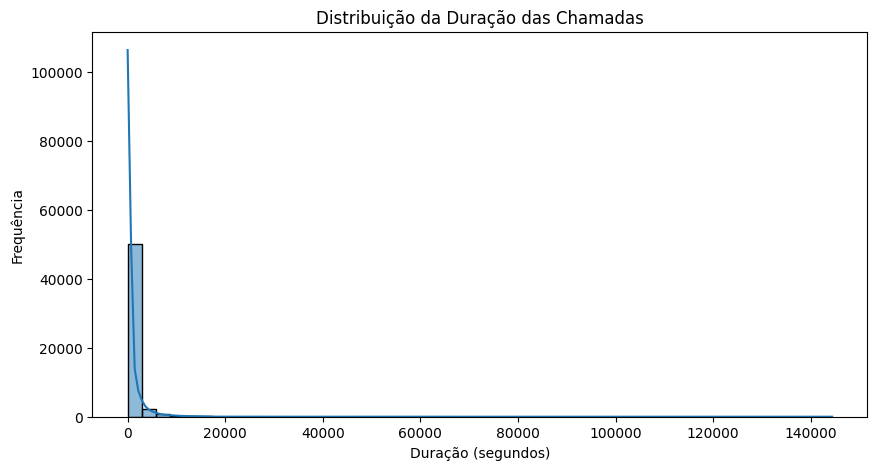

In [92]:

plt.figure(figsize=(10,5))
sns.histplot(df_calls['call_duration'], bins=50, kde=True)
plt.title("Distribuição da Duração das Chamadas")
plt.xlabel("Duração (segundos)")
plt.ylabel("Frequência")
plt.show()


O histograma mostra que a grande maioria das chamadas possui duração muito curta, com uma queda rápida na frequência conforme a duração aumenta. A distribuição apresenta uma cauda longa, indicando que poucas chamadas duram muito tempo. Esse comportamento revela um uso altamente concentrado em chamadas curtas.

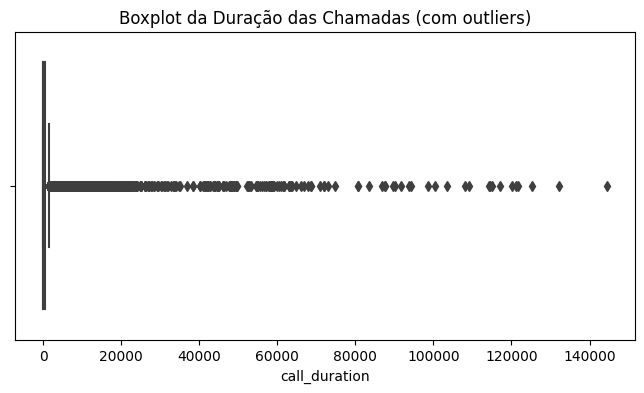

In [93]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_calls['call_duration'])
plt.title("Boxplot da Duração das Chamadas (com outliers)")
plt.show()

O boxplot com outliers evidencia a presença de valores extremamente altos de duração. Esses pontos distantes do corpo principal dos dados mostram que existem chamadas atípicas que fogem completamente do padrão normal de uso e podem distorcer métricas como a média.


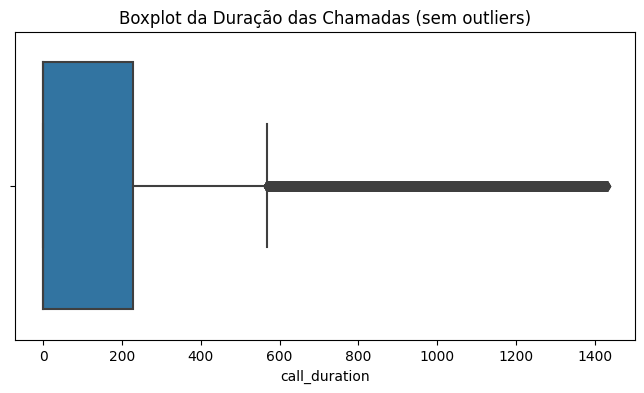

In [94]:
Q1 = df_calls['call_duration'].quantile(0.25)
Q3 = df_calls['call_duration'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

df_sem_outliers = df_calls[df_calls['call_duration'] <= limite_superior]

plt.figure(figsize=(8,4))
sns.boxplot(x=df_sem_outliers['call_duration'])
plt.title("Boxplot da Duração das Chamadas (sem outliers)")
plt.show()

Ao remover os outliers, o boxplot revela a distribuição real e mais representativa das chamadas. A maior parte das durações se concentra em valores baixos, com variação moderada. Esse gráfico permite observar o comportamento típico dos usuários sem a influência de valores extremos.

In [95]:

(df_calls['call_duration'] == 0).mean() * 100



43.15795332269675

O cálculo mostra que 43,15% das chamadas registradas possuem duração igual a zero. Esse indicador é importante porque chamadas sem duração podem refletir falhas técnicas, interrupções imediatas ou problemas de usabilidade. Monitorar esse KPI ajuda a avaliar a qualidade operacional do serviço e a identificar possíveis pontos de melhoria na experiência do cliente.

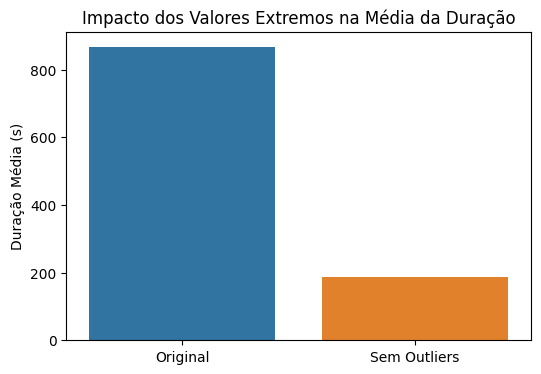

In [96]:
media_original = df_calls['call_duration'].mean()
media_limpa = df_sem_outliers['call_duration'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=["Original", "Sem Outliers"], y=[media_original, media_limpa])
plt.title("Impacto dos Valores Extremos na Média da Duração")
plt.ylabel("Duração Média (s)")
plt.show()


O gráfico compara a média original da duração das chamadas com a média após remover valores extremos. A diferença significativa entre as duas barras mostra que os valores muito altos de duração têm forte influência sobre a média, distorcendo a percepção real do comportamento típico dos usuários. Esse KPI é essencial para garantir que as métricas utilizadas na análise representem de forma fiel o uso do serviço.

In [97]:
percentual_outliers = (df_calls['call_duration'] > limite_superior).mean() * 100
percentual_outliers


14.045861007012729

O cálculo mostra que 14,05% das chamadas são classificadas como outliers, ou seja, possuem duração acima do limite considerado típico pelo método estatístico adotado. Esse KPI é importante porque quantifica o volume de valores extremos presentes no conjunto de dados, permitindo avaliar o quanto esses pontos podem influenciar métricas globais e distorcer a interpretação do comportamento real dos usuários.

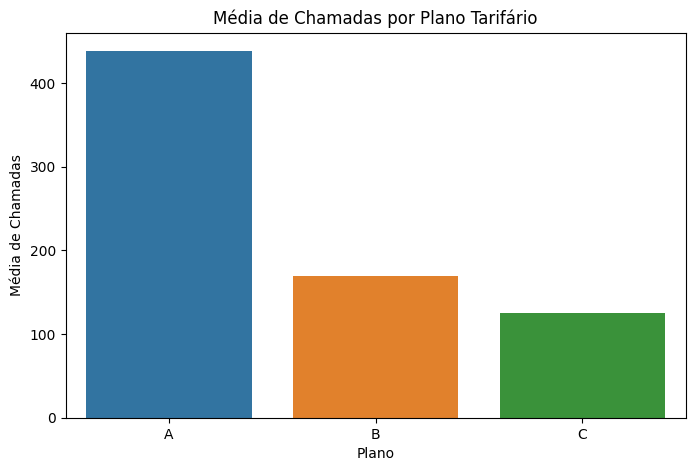

In [98]:
media_plano = df_uso_plano.groupby('tariff_plan')['num_chamadas'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=media_plano, x='tariff_plan', y='num_chamadas')
plt.title("Média de Chamadas por Plano Tarifário")
plt.xlabel("Plano")
plt.ylabel("Média de Chamadas")
plt.show()


O gráfico mostra que os usuários do Plano A realizam, em média, muito mais chamadas do que os usuários dos Planos B e C. O Plano B apresenta um volume intermediário, enquanto o Plano C possui a menor média de chamadas. Essa diferença evidencia que os planos atraem perfis de uso distintos, indicando que o Plano A concentra clientes com comportamento de uso mais intenso.

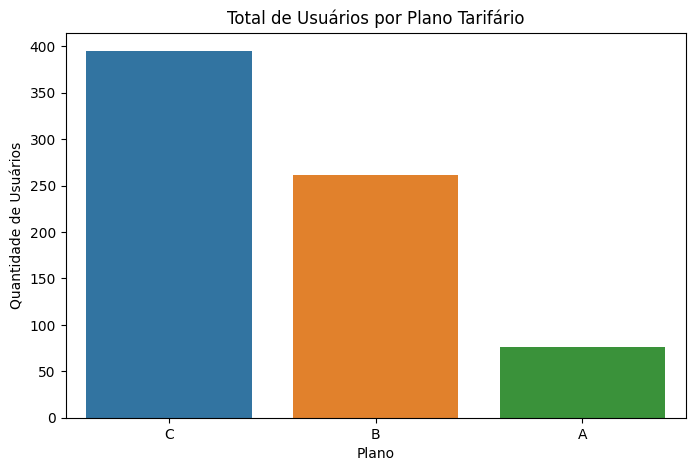

In [99]:
usuarios_plano = df_clients['tariff_plan'].value_counts().reset_index()
usuarios_plano.columns = ['tariff_plan', 'count']

plt.figure(figsize=(8,5))
sns.barplot(data=usuarios_plano, x='tariff_plan', y='count')
plt.title("Total de Usuários por Plano Tarifário")
plt.xlabel("Plano")
plt.ylabel("Quantidade de Usuários")
plt.show()

O gráfico mostra que o Plano C concentra a maior parte dos usuários, enquanto o Plano A possui a menor base, apesar de ser o plano com maior intensidade de uso. Essa diferença sugere que os planos atraem perfis distintos: muitos usuários leves no Plano C e poucos heavy users no Plano A. No futuro, pode ser interessante avaliar formas de tornar o Plano B mais atrativo, incentivando uma migração natural de parte dos usuários do Plano C.

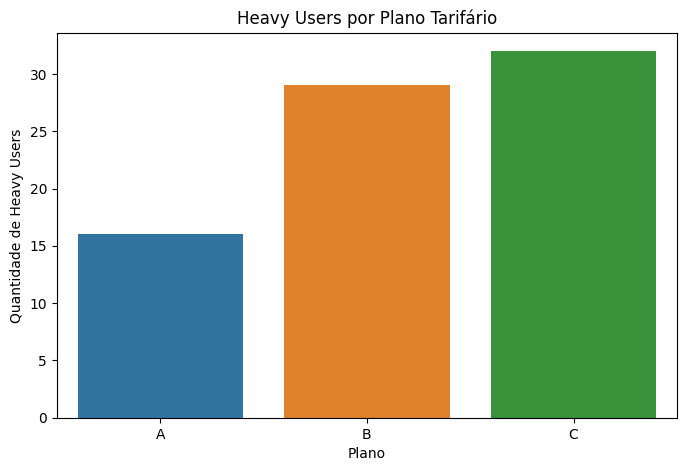

In [100]:
limite_heavy = df_uso_plano['num_chamadas'].quantile(0.75)
heavy_users = df_uso_plano[df_uso_plano['num_chamadas'] > limite_heavy]
heavy_por_plano = heavy_users.groupby('tariff_plan')['user_id'].count().reset_index()
heavy_por_plano.columns = ['tariff_plan', 'heavy_users']

plt.figure(figsize=(8,5))
sns.barplot(data=heavy_por_plano, x='tariff_plan', y='heavy_users')
plt.title("Heavy Users por Plano Tarifário")
plt.xlabel("Plano")
plt.ylabel("Quantidade de Heavy Users")
plt.show()

O gráfico mostra que o Plano C concentra o maior número absoluto de heavy users, o que é esperado por ter a maior base de clientes. O ponto mais relevante, porém, é que o Plano B aparece muito próximo do Plano C, mesmo tendo uma base significativamente menor. Isso indica que o Plano B atrai um perfil de uso mais intenso do que o Plano C, sugerindo potencial para fortalecer esse plano como alternativa intermediária para usuários que hoje estão no Plano C.

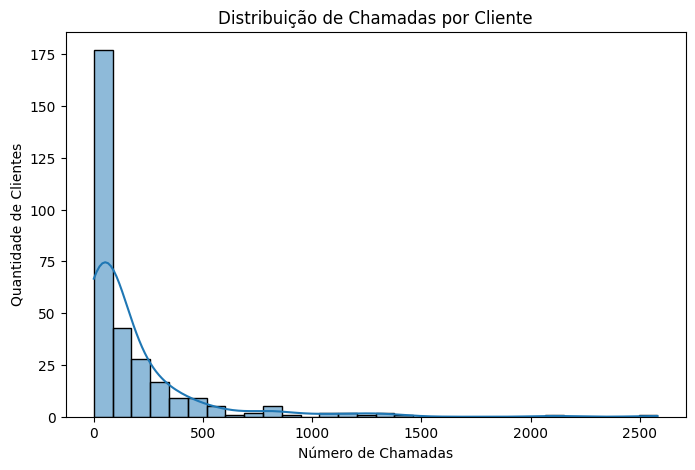

In [101]:
plt.figure(figsize=(8,5))
sns.histplot(df_uso_plano['num_chamadas'], bins=30, kde=True)
plt.title("Distribuição de Chamadas por Cliente")
plt.xlabel("Número de Chamadas")
plt.ylabel("Quantidade de Clientes")
plt.show()

A distribuição é fortemente concentrada nos níveis mais baixos de uso: a maioria dos clientes realiza poucas chamadas, enquanto uma minoria muito pequena concentra volumes extremamente altos. Esse padrão confirma a presença de uma cauda longa típica, onde poucos usuários representam grande parte do consumo total. Esse comportamento reforça a importância dos heavy users na dinâmica geral de utilização.

A análise dos KPIs confirma que o comportamento de uso varia significativamente entre os planos tarifários. O Plano A, apesar de ter a menor base de clientes, concentra usuários com uso muito intenso, enquanto o Plano C, que possui a maior base, apresenta o menor volume médio de chamadas. O Plano B surge como um ponto intermediário, mas com um nível de heavy users surpreendentemente próximo ao do Plano C, mesmo com uma base muito menor. A distribuição geral de chamadas reforça a presença de uma cauda longa, onde poucos clientes representam grande parte do consumo total. Esses padrões validam a hipótese de que os planos atraem perfis distintos de utilização.

Plano de Ação — Otimização dos Planos Tarifários
Fortalecer o Plano B como opção intermediária  
O Plano B demonstra um comportamento de uso mais intenso do que o esperado para sua base reduzida. Isso indica potencial para posicioná‑lo como uma alternativa mais atrativa para usuários do Plano C que apresentam tendência de crescimento no consumo.

Criar incentivos de migração do Plano C → Plano B  
Como o Plano C concentra muitos usuários leves, mas também uma parcela relevante de heavy users, oferecer benefícios moderados (ex.: minutos adicionais, pequenas vantagens de preço ou serviços complementares) pode estimular a migração natural para o Plano B.

Manter atenção especial aos heavy users do Plano A  
Apesar da base pequena, esses clientes concentram grande parte do uso total. Estratégias de retenção e benefícios exclusivos podem evitar churn e preservar receita de alto valor.

Monitorar evolução do consumo no Plano C  
A cauda longa indica que alguns usuários podem estar próximos de ultrapassar o perfil do plano. Acompanhamento contínuo permite identificar momentos ideais para sugerir upgrades

In [102]:
df_uso_plano.to_csv('dados_uso_plano_telecom.csv', index=False)
print("Arquivo exportado com sucesso!")

Arquivo exportado com sucesso!


In [103]:
import os
print("Diretório atual:", os.getcwd())
print("Arquivos no diretório:", [f for f in os.listdir('.') if f.endswith('.csv')])

Diretório atual: /app
Arquivos no diretório: ['dados_uso_plano_telecom.csv']


In [104]:
import os
os.getcwd()

'/app'

In [105]:
import os
os.path.abspath("dados_uso_plano_telecom.csv")

'/app/dados_uso_plano_telecom.csv'

In [106]:
df_uso_plano.head()

,user_id,num_chamadas,tariff_plan
0,166377,571,B
1,166391,20,C
2,166392,107,C
3,166399,23,C
4,166405,1042,B


<div class="alert alert-block alert-success">
<b> Comentário geral do revisor</b> <a class="tocSkip"></a>

Obrigado por enviar o seu projeto e pelo esforço de chegar até aqui. A organização e apresentação do seu projeto estão excelentes. Seguem alguns pontos como sugestão:

- Você pode analisar a correlação entre as chamadas e atributos numéricos e/ou categóricos
- Usar técnicas de agrupamento (Kmeans, por exemplo) para agrupar os usuários com base em seu comportamento. Dessa forma, você poderia pensar em estratégias de marketing específicas para cada grupo de usuários
- Realizar uma análise de sobrevivência para responder à seguinte pergunta: a partir de quantas chamadas um cliente é "fidelizado"? Pense no esforço mínimo que a empresa precisa investir para conquistar um cliente fidelizado.
- Você pode treinar um modelo de classificação para prever ineficiência operacional.
       
<br>   
    
Qualquer dúvida, pode contar comigo.   
    
<br>  
    
**Até breve!**

</div>